In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# Peak Hour on the Corridor — Peak-Hour Factors and Peak-Hour Potential Movements (2022 layers)

The corridor profiles of steps 17–18 are **three-hour totals** (06:00–09:00). Station and service design need the busiest hour. This notebook derives **peak-hour factors** from the survey's minute-level departure times and applies them to the 2022 link profiles.

**Source of the timing.** The trips file records the departure time of every trip to the minute (`STDep`, decimal hours; `Dep_h` is its floor). Trips are the same AM trips as in step 15 (both ends in the study area), allocated to TAZs and to the 28 sub-areas with the same population / employment split. For each mode layer the departure-time distribution is built in 15-minute bins over 06:00–09:00 and the **peak hour** is the 60-minute window (in 15-minute steps) holding the largest share. Two factors are reported:

- **PHF₃ₕ** = peak-hour trips / three-hour trips — the factor that turns a three-hour profile into a peak-hour one (the "divide by 3" of an average hour corresponds to 0.333);
- **PHF₆₀** = peak-hour trips / (4 × busiest 15 minutes) — the conventional within-hour peak-hour factor (1.0 = flat hour).

**Level of the factors.** Departure-time profiles are computed for the trips that make up the corridor profile — trips between two line areas, per **direction** (towards Nazareth 1 → 23, towards Tirat Carmel 23 → 1) and per **mode layer** (car; bus = Public Bus + Matronit; taxi-type), weighted by the number of links each trip crosses so that the profile describes link crossings. Rail uses the bus profile (54 sampled rail trips, none between line areas). Per-link profiles are also computed as a check on the busiest links, and a 200-replicate household bootstrap gives the sampling range of each factor. Study-area-wide profiles by mode are shown for context.

**Timing frame.** The factor is on *departure* time. A trip departing at 07:30 crosses a link 10–40 minutes later, so the peak-hour link flow is a departure-hour quantity; a link-crossing window would be shifted later by roughly the mean travel time to the link, and would be slightly flatter. Ticketing (RavKav) carries the boarding hour and would give an independent bus peak factor; the raw files are Git-LFS-only and not available here (task list, B1e).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, PURPLE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
OUT = 'Output/ths2017/three_mode_2022'; os.makedirs('Output/figures', exist_ok=True)
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

# ---- survey trips with minute-level departure time (same extraction as step 15) ----
df = pd.read_excel('Input/trips_ths_2017.xlsx')
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy(); g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1); d['trip_dep_h'] = g['Dep_h'].shift(1); d['dep'] = g['STDep'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h']); trips = trips[trips['trip_dep_h'].isin([6, 7, 8])].copy()
assert (trips['trip_dep_h'] == np.floor(trips['dep'])).mean() > 0.99
NB = 12; trips['bin'] = ((trips['dep'] - 6.0) * 4).astype(int).clip(0, NB - 1)      # 15-minute bins 06:00–09:00
COMP = {'CAR': [10, 11], 'BUS': [3, 4], 'TAXI': [5, 8], 'RAIL': [7]}
def comp_of(m):
    for k, v in COMP.items():
        if m in v: return k
    return 'OTHER'
trips['comp'] = trips['mainmode'].map(comp_of)

k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636'); map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']
trips['o1250'] = trips['origin'].map(map_2636_1250); trips['d1250'] = trips['actTaz'].map(map_2636_1250)
KEYS_LFS = 'Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv'
keys_raw = pd.read_csv('Input/taz_keys_from_shapefile.csv') if open(KEYS_LFS, 'rb').read(40).startswith(b'version https://git-lfs') else pd.read_csv(KEYS_LFS, encoding='windows-1255')
kd = keys_raw[['TAZ_1270', 'TAZ_NUMBER', 'SZ_NEW']].dropna(subset=['TAZ_NUMBER']).astype({'TAZ_NUMBER': int, 'SZ_NEW': int}).drop_duplicates('TAZ_NUMBER')
TAZ = np.array(sorted(kd['TAZ_NUMBER'])); N = len(TAZ); taz_pos = {t: i for i, t in enumerate(TAZ)}
children = kd.groupby('TAZ_1270')['TAZ_NUMBER'].apply(list); north_1250 = sorted(children.index); z_idx = {z: i for i, z in enumerate(north_1250)}
tm = trips[trips['o1250'].isin(z_idx) & trips['d1250'].isin(z_idx)].copy(); tm['oi'] = tm['o1250'].map(z_idx); tm['di'] = tm['d1250'].map(z_idx)
zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID').reindex(TAZ)
pop, emp = zon['POPULATION'].fillna(0).values, zon['EMPL_TOT'].fillna(0).values
def alloc(primary, secondary):
    S = np.zeros((len(north_1250), N))
    for z, kids in children.items():
        idx = [taz_pos[t] for t in kids]
        for v in (primary[idx], secondary[idx], np.ones(len(idx))):
            if v.sum() > 0: S[z_idx[z], idx] = v / v.sum(); break
    return S
S_o, S_d = alloc(pop, emp), alloc(emp, pop)
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx'); area_of = sub_key.set_index('TAZ')['AggAreaCode']; AREA = sorted(area_of.unique())
M_area = np.zeros((N, len(AREA))); apos = {a: i for i, a in enumerate(AREA)}
for i, t in enumerate(TAZ):
    if t in area_of.index: M_area[i, apos[area_of[t]]] = 1
SA_o, SA_d = S_o @ M_area, S_d @ M_area                     # 1250-zone -> area allocation shares (rows sum to <= 1: zones outside the sub-area drop out)
legend = pd.read_csv('Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode'); names = legend['AggAreaName']
ref = pd.read_csv(f'{OUT}/corridor_link_flows_transit_2022.csv'); SEQ = list(ref['from_code']) + [int(ref['to_code'].iloc[-1])]
spos = {a: i for i, a in enumerate(SEQ)}; L = len(SEQ) - 1
print(f"AM trips in the study area: {len(tm):,} sampled; line sequence of {len(SEQ)} areas, {L} links")

AM trips in the study area: 26,863 sampled; line sequence of 18 areas, 17 links


## 1. Departure-time profiles of the trips that make up the corridor profile

In [3]:
# For each sampled trip: its allocation to line-area pairs (o_area, d_area) with weight share_o * share_d; direction and links crossed follow.
seq_cols = np.array([apos[a] for a in SEQ])
def line_pair_shares(sub):
    # returns long table: trip index, o_pos, d_pos (positions on the line), share (product of allocation shares)
    So = SA_o[sub['oi'].values][:, seq_cols]; Sd = SA_d[sub['di'].values][:, seq_cols]
    rows = []
    nz = np.argwhere(So > 0); nzd = np.argwhere(Sd > 0)
    so = {}; sd = {}
    for r, c in nz: so.setdefault(r, []).append((c, So[r, c]))
    for r, c in nzd: sd.setdefault(r, []).append((c, Sd[r, c]))
    for r in set(so) & set(sd):
        for co, wo in so[r]:
            for cd, wd in sd[r]:
                if co != cd: rows.append((r, co, cd, wo * wd))
    t = pd.DataFrame(rows, columns=['row', 'o_pos', 'd_pos', 'share'])
    t['dir'] = np.where(t['d_pos'] > t['o_pos'], '1→23', '23→1'); t['links'] = (t['d_pos'] - t['o_pos']).abs()
    return t

LAYERS = ['CAR', 'BUS', 'TAXI']
prof = {}; nsamp = {}
for comp in LAYERS:
    sub = tm[tm['comp'] == comp].reset_index(drop=True)
    lp = line_pair_shares(sub)
    lp['w'] = lp['share'] * sub['new_wf'].values[lp['row']] * lp['links']      # link-crossing weight (expanded)
    lp['bin'] = sub['bin'].values[lp['row']]; lp['hh'] = sub['HHID3'].values[lp['row']]
    prof[comp] = lp
    nsamp[comp] = {d_: int(lp.loc[lp['dir'] == d_, 'row'].nunique()) for d_ in ['1→23', '23→1']}
    print(f"{comp}: sampled trips with an allocation to a line-area pair — towards Nazareth {nsamp[comp]['1→23']}, towards Tirat Carmel {nsamp[comp]['23→1']}")

def window_stats(w_by_bin):
    s = np.asarray(w_by_bin, float); tot = s.sum()
    if tot <= 0: return dict(PHF3h=np.nan, start=np.nan, PHF60=np.nan, h6=np.nan, h7=np.nan, h8=np.nan)
    p = s / tot; win = np.array([p[i:i + 4].sum() for i in range(NB - 3)]); k = int(np.argmax(win))
    return dict(PHF3h=win[k], start=6 + k / 4, PHF60=win[k] / (4 * p[k:k + 4].max()), h6=p[:4].sum(), h7=p[4:8].sum(), h8=p[8:].sum())

rows = []
for comp in LAYERS:
    for d_ in ['1→23', '23→1']:
        lp = prof[comp][prof[comp]['dir'] == d_]
        st = window_stats(lp.groupby('bin')['w'].sum().reindex(range(NB)).fillna(0).values)
        rows.append({'level': 'corridor, by direction', 'layer': comp, 'direction': d_, 'n sampled': nsamp[comp][d_], **st})
    st = window_stats(prof[comp].groupby('bin')['w'].sum().reindex(range(NB)).fillna(0).values)
    rows.append({'level': 'corridor, both directions', 'layer': comp, 'direction': 'both', 'n sampled': sum(nsamp[comp].values()), **st})
for comp in LAYERS + ['RAIL', 'OTHER']:
    sub = tm[tm['comp'] == comp]
    st = window_stats(sub.groupby('bin')['new_wf'].sum().reindex(range(NB)).fillna(0).values)
    rows.append({'level': 'study area, all trips', 'layer': comp, 'direction': '—', 'n sampled': len(sub), **st})
phf = pd.DataFrame(rows)
phf['peak hour'] = phf['start'].map(lambda s: f"{int(s):02d}:{int((s % 1) * 60):02d}–{int(s + 1):02d}:{int((s % 1) * 60):02d}" if pd.notna(s) else '')
print(phf.round(3).to_string(index=False))

CAR: sampled trips with an allocation to a line-area pair — towards Nazareth 194, towards Tirat Carmel 236
BUS: sampled trips with an allocation to a line-area pair — towards Nazareth 48, towards Tirat Carmel 26
TAXI: sampled trips with an allocation to a line-area pair — towards Nazareth 35, towards Tirat Carmel 25
                    level layer direction  n sampled  PHF3h  start  PHF60    h6    h7    h8   peak hour
   corridor, by direction   CAR      1→23        194  0.661   7.25  0.885 0.162 0.510 0.328 07:15–08:15
   corridor, by direction   CAR      23→1        236  0.626   7.00  0.656 0.174 0.626 0.200 07:00–08:00
corridor, both directions   CAR      both        430  0.576   7.00  0.680 0.169 0.576 0.255 07:00–08:00
   corridor, by direction   BUS      1→23         48  0.655   7.25  0.591 0.048 0.532 0.420 07:15–08:15
   corridor, by direction   BUS      23→1         26  0.435   6.00  0.595 0.435 0.160 0.405 06:00–07:00
corridor, both directions   BUS      both         74  0.50

## 2. Sampling range of the factors — household bootstrap

In [4]:
rng = np.random.default_rng(7); B = 200
boot = {}
for comp in LAYERS:
    lp = prof[comp]; hh = lp['hh'].values; hh_ids = np.unique(hh); hh_pos = {h: i for i, h in enumerate(hh_ids)}; hidx = np.array([hh_pos[h] for h in hh])
    for d_ in ['1→23', '23→1']:
        m = (lp['dir'] == d_).values; vals3, vals60 = [], []
        for _ in range(B):
            mult = np.bincount(rng.integers(0, len(hh_ids), len(hh_ids)), minlength=len(hh_ids))   # household resampling weights
            w = lp['w'].values[m] * mult[hidx[m]]
            s = np.bincount(lp['bin'].values[m], weights=w, minlength=NB); st = window_stats(s)
            vals3.append(st['PHF3h']); vals60.append(st['PHF60'])
        boot[(comp, d_)] = (np.nanpercentile(vals3, 5), np.nanpercentile(vals3, 95), np.nanpercentile(vals60, 5), np.nanpercentile(vals60, 95))
phf['PHF3h p5'] = [boot.get((r.layer, r.direction), (np.nan,) * 4)[0] for r in phf.itertuples()]
phf['PHF3h p95'] = [boot.get((r.layer, r.direction), (np.nan,) * 4)[1] for r in phf.itertuples()]
phf['PHF60 p5'] = [boot.get((r.layer, r.direction), (np.nan,) * 4)[2] for r in phf.itertuples()]
phf['PHF60 p95'] = [boot.get((r.layer, r.direction), (np.nan,) * 4)[3] for r in phf.itertuples()]
phf.to_csv(f'{OUT}/peak_hour_factors.csv', index=False, float_format='%.4f')
print(phf[phf['level'] == 'corridor, by direction'][['layer', 'direction', 'n sampled', 'peak hour', 'PHF3h', 'PHF3h p5', 'PHF3h p95', 'PHF60', 'PHF60 p5', 'PHF60 p95']].round(3).to_string(index=False))

layer direction  n sampled   peak hour  PHF3h  PHF3h p5  PHF3h p95  PHF60  PHF60 p5  PHF60 p95
  CAR      1→23        194 07:15–08:15  0.661     0.510      0.809  0.885     0.546      0.871
  CAR      23→1        236 07:00–08:00  0.626     0.474      0.749  0.656     0.456      0.788
  BUS      1→23         48 07:15–08:15  0.655     0.540      0.844  0.591     0.370      0.702
  BUS      23→1         26 06:00–07:00  0.435     0.430      0.787  0.595     0.302      0.650
 TAXI      1→23         35 06:45–07:45  0.784     0.593      0.935  0.395     0.304      0.695
 TAXI      23→1         25 07:00–08:00  0.837     0.629      0.948  0.418     0.284      0.544


## 3. Per-link check — does one factor per direction and layer hold along the line?

In [5]:
# link-level 15-minute profiles from the survey trips themselves (2018 survey volumes; timing only)
def link_bins(lp):
    F = np.zeros((2, L, NB)); Nn = np.zeros((2, L))               # dir x link x bin (expanded), and sampled-trip equivalents per link
    for r in lp.itertuples():
        di = 0 if r.dir == '1→23' else 1; a, b = sorted((r.o_pos, r.d_pos))
        F[di, a:b, r.bin] += r.w / r.links                          # per-link weight = expanded trips (undo the link multiplicity)
        Nn[di, a:b] += r.share
    return F, Nn
link_rows = []
for comp in LAYERS:
    F, Nn = link_bins(prof[comp])
    for di, d_ in enumerate(['1→23', '23→1']):
        for l in range(L):
            st = window_stats(F[di, l]); link_rows.append({'layer': comp, 'direction': d_, 'link': f'{names[SEQ[l]]} – {names[SEQ[l + 1]]}', 'survey trips 2018 (3 h)': F[di, l].sum(), 'sampled trips (equiv.)': Nn[di, l], 'PHF3h link': st['PHF3h'], 'peak start link': st['start']})
lk = pd.DataFrame(link_rows)
dirfac = phf[phf['level'] == 'corridor, by direction'].set_index(['layer', 'direction'])['PHF3h']
lk['PHF3h direction'] = [dirfac[(r.layer, r.direction)] for r in lk.itertuples()]
lk['diff'] = lk['PHF3h link'] - lk['PHF3h direction']
N_MIN_LINK = 30
big = lk[lk['sampled trips (equiv.)'] >= N_MIN_LINK]
lk.to_csv(f'{OUT}/peak_hour_factors_by_link.csv', index=False, float_format='%.4f')
print(f"links × directions with ≥ {N_MIN_LINK} sampled trips: {len(big)} of {len(lk)} (by layer: {big.groupby('layer').size().to_dict()})")
print(f"per-link PHF3h minus direction PHF3h on them — mean {big['diff'].mean():+.3f}, p10 {big['diff'].quantile(.1):+.3f}, p90 {big['diff'].quantile(.9):+.3f}")
print(big.groupby('layer')['diff'].describe()[['count', 'mean', 'min', 'max']].round(3))
print("\nbus links with the most sampled trips:"); print(lk[lk['layer'] == 'BUS'].sort_values('sampled trips (equiv.)', ascending=False).head(8)[['direction', 'link', 'sampled trips (equiv.)', 'PHF3h link', 'PHF3h direction']].round(3).to_string(index=False))

links × directions with ≥ 30 sampled trips: 19 of 102 (by layer: {'CAR': 19})
per-link PHF3h minus direction PHF3h on them — mean +0.029, p10 -0.121, p90 +0.188
       count   mean   min    max
layer                           
CAR     19.0  0.029 -0.15  0.233

bus links with the most sampled trips:
direction                       link  sampled trips (equiv.)  PHF3h link  PHF3h direction
     1→23      Ein Hayam – Bat Galim                  24.748       0.660            0.655
     1→23 Bat Galim – Kiryat Eliezer                  23.914       0.738            0.655
     1→23     Hamoshava – Lower City                  23.865       0.716            0.655
     1→23 Kiryat Eliezer – Hamoshava                  23.865       0.716            0.655
     1→23  Lower City – Hadar Carmel                  16.320       0.620            0.655
     1→23     Neve David – Ein Hayam                  14.912       0.684            0.655
     23→1 Kiryat Eliezer – Hamoshava                   7.880       0.4

## 4. Peak-hour potential movements on the 2022 link profiles

In [6]:
links3h = {k: pd.read_csv(f'{OUT}/corridor_link_flows_{k}_2022.csv') for k in ['total', 'transit', 'taxi']}
car3h = pd.read_csv(f'{OUT}/car_2022_area.csv', index_col=0); car3h.index = car3h.index.astype(int); car3h.columns = car3h.columns.astype(int)
rail3h = pd.read_csv(f'{OUT}/rail_2022_area.csv', index_col=0); rail3h.index = rail3h.index.astype(int); rail3h.columns = rail3h.columns.astype(int)
def link_flows(m):
    sub = m.reindex(index=SEQ, columns=SEQ).fillna(0).values; f, b = np.zeros(L), np.zeros(L)
    for i in range(len(SEQ)):
        for j in range(len(SEQ)):
            if i < j: f[i:j] += sub[i, j]
            elif i > j: b[j:i] += sub[i, j]
    return f, b
car_f, car_b = link_flows(car3h); rail_f, rail_b = link_flows(rail3h)
# ---- which factor is applied: direction-level where the corridor sample supports it (>= 100 sampled trips), otherwise the study-area factor of the layer
N_MIN_DIR = 100
areafac = phf[phf['level'] == 'study area, all trips'].set_index('layer')['PHF3h']
poolfac = phf[phf['level'] == 'corridor, both directions'].set_index('layer')['PHF3h']
def factor(layer, d_):
    n = nsamp[layer][d_]
    return (dirfac[(layer, d_)], f'corridor, direction ({n} sampled)') if n >= N_MIN_DIR else (areafac[layer], f'study area, all trips ({int(phf[(phf.level == "study area, all trips") & (phf.layer == layer)]["n sampled"].iloc[0])} sampled)')
applied = pd.DataFrame([{'layer': k, 'direction': d_, 'PHF3h applied': factor(k, d_)[0], 'basis': factor(k, d_)[1], 'corridor direction value': dirfac[(k, d_)], 'corridor pooled value': poolfac[k], 'study-area value': areafac[k]} for k in LAYERS for d_ in ['1→23', '23→1']])
applied.to_csv(f'{OUT}/peak_hour_factors_applied.csv', index=False, float_format='%.4f')
print(applied.round(3).to_string(index=False))
out = pd.DataFrame({'link': [f'{names[a]} – {names[b]}' for a, b in zip(SEQ[:-1], SEQ[1:])]})
for d_, col, carv, railv in [('1→23', 'flow_dir_1_to_23', car_f, rail_f), ('23→1', 'flow_dir_23_to_1', car_b, rail_b)]:
    f = {k: factor(k, d_)[0] for k in LAYERS}
    bus3 = links3h['transit'][col].values - railv; taxi3 = links3h['taxi'][col].values
    out[f'car 3h {d_}'] = carv; out[f'bus 3h {d_}'] = bus3; out[f'taxi 3h {d_}'] = taxi3; out[f'rail 3h {d_}'] = railv
    out[f'transit 3h {d_}'] = bus3 + railv; out[f'total 3h {d_}'] = links3h['total'][col].values
    out[f'car peak {d_}'] = carv * f['CAR']; out[f'bus peak {d_}'] = bus3 * f['BUS']; out[f'taxi peak {d_}'] = taxi3 * f['TAXI']; out[f'rail peak {d_}'] = railv * f['BUS']
    out[f'transit peak {d_}'] = out[f'bus peak {d_}'] + out[f'rail peak {d_}']
    out[f'total peak {d_}'] = out[f'car peak {d_}'] + out[f'bus peak {d_}'] + out[f'taxi peak {d_}'] + out[f'rail peak {d_}']
    out[f'transit avg hour {d_}'] = out[f'transit 3h {d_}'] / 3; out[f'total avg hour {d_}'] = out[f'total 3h {d_}'] / 3
    assert np.allclose(out[f'total 3h {d_}'], carv + bus3 + taxi3 + railv, atol=1.5), 'link totals must add up across layers'
out.to_csv(f'{OUT}/corridor_link_flows_peak_hour_2022.csv', index=False, float_format='%.1f')
# sensitivity of the busiest transit link to the choice of bus factor
sens = []
for d_ in ['1→23', '23→1']:
    k = out[f'transit peak {d_}'].idxmax(); bus3 = out.loc[k, f'bus 3h {d_}']; rail3 = out.loc[k, f'rail 3h {d_}']
    for lab, fb in [('study area (applied)', areafac['BUS']), ('corridor pooled', poolfac['BUS']), ('corridor direction', dirfac[('BUS', d_)]), ('average hour (÷ 3)', 1 / 3)]:
        sens.append({'direction': d_, 'link': out.loc[k, 'link'], 'bus factor basis': lab, 'PHF3h bus': fb, 'transit peak-hour trips': bus3 * fb + rail3 * fb})
sens = pd.DataFrame(sens); sens.to_csv(f'{OUT}/peak_hour_sensitivity.csv', index=False, float_format='%.3f'); print(sens.round(3).to_string(index=False))
show = out[['link', 'transit 3h 1→23', 'transit peak 1→23', 'total 3h 1→23', 'total peak 1→23', 'transit 3h 23→1', 'transit peak 23→1', 'total 3h 23→1', 'total peak 23→1']].round(0)
for d_ in ['1→23', '23→1']:
    k = out[f'transit peak {d_}'].idxmax(); kt = out[f'total peak {d_}'].idxmax()
    print(f"{d_}: peak-hour transit max {out.loc[k, f'transit peak {d_}']:,.0f} on {out.loc[k, 'link']} (3 h {out.loc[k, f'transit 3h {d_}']:,.0f}, average hour {out.loc[k, f'transit avg hour {d_}']:,.0f}); "
          f"peak-hour total max {out.loc[kt, f'total peak {d_}']:,.0f} on {out.loc[kt, 'link']}")
show

layer direction  PHF3h applied                                basis  corridor direction value  corridor pooled value  study-area value
  CAR      1→23          0.661    corridor, direction (194 sampled)                     0.661                  0.576             0.621
  CAR      23→1          0.626    corridor, direction (236 sampled)                     0.626                  0.576             0.621
  BUS      1→23          0.590 study area, all trips (1636 sampled)                     0.655                  0.503             0.590
  BUS      23→1          0.590 study area, all trips (1636 sampled)                     0.435                  0.503             0.590
 TAXI      1→23          0.580  study area, all trips (253 sampled)                     0.784                  0.774             0.580
 TAXI      23→1          0.580  study area, all trips (253 sampled)                     0.837                  0.774             0.580
direction                    link     bus factor basis 

,link,transit 3h 1→23,transit peak 1→23,total 3h 1→23,total peak 1→23,transit 3h 23→1,transit peak 23→1,total 3h 23→1,total peak 23→1
0,TiratCarmel – Matam,662.0,391.0,4095.0,2612.0,217.0,128.0,1538.0,939.0
1,Matam – Neot Peres,789.0,466.0,3410.0,2151.0,1007.0,594.0,3713.0,2263.0
2,Neot Peres – Neve David,655.0,387.0,3286.0,2078.0,1650.0,974.0,4703.0,2849.0
3,Neve David – Ein Hayam,1217.0,718.0,5073.0,3190.0,1467.0,866.0,4578.0,2779.0
4,Ein Hayam – Bat Galim,1661.0,981.0,7326.0,4609.0,1222.0,721.0,3869.0,2349.0
5,Bat Galim – Kiryat Eliezer,1518.0,896.0,6852.0,4339.0,1355.0,800.0,6847.0,4205.0
6,Kiryat Eliezer – Hamoshava,1512.0,893.0,6713.0,4277.0,1079.0,637.0,4964.0,3050.0
7,Hamoshava – Lower City,1428.0,843.0,5750.0,3628.0,1146.0,677.0,3749.0,2285.0
8,Lower City – Hadar Carmel,1149.0,678.0,4477.0,2834.0,1334.0,788.0,4552.0,2776.0
9,Hadar Carmel – Namal,729.0,430.0,3038.0,1917.0,1538.0,908.0,4153.0,2524.0


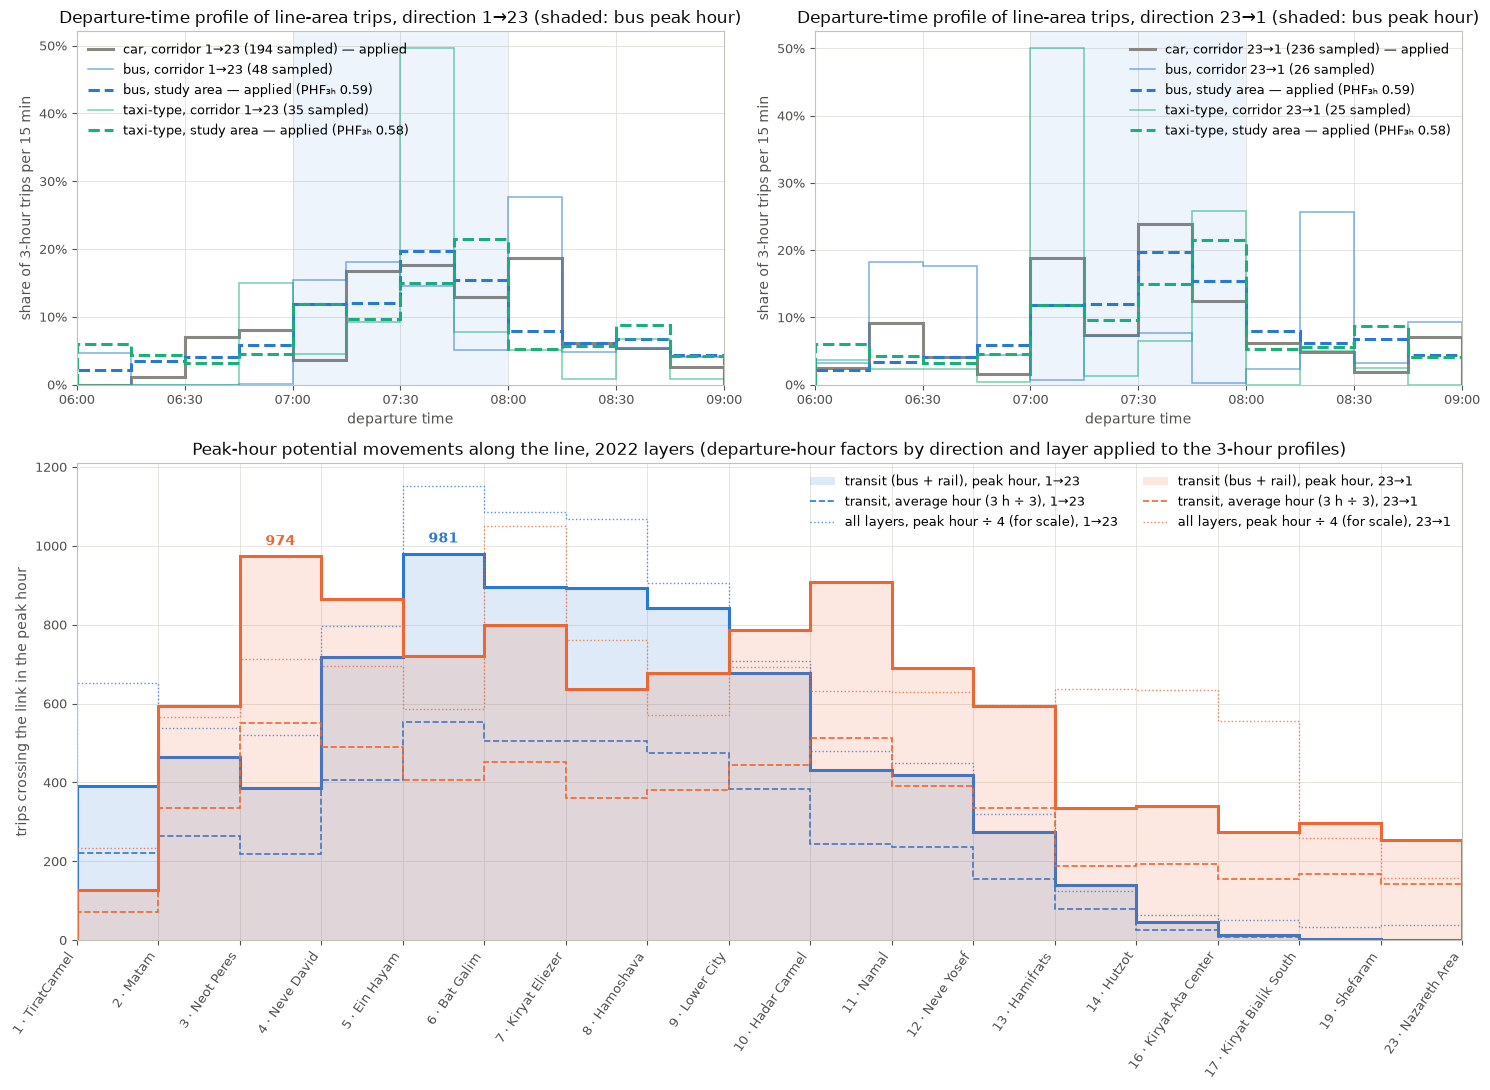

In [7]:
fig = plt.figure(figsize=(15, 11), facecolor='white'); gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.35])
x15 = 6 + np.arange(NB) / 4
for j, d_ in enumerate(['1→23', '23→1']):
    ax = fig.add_subplot(gs[0, j])
    for comp, color in [('CAR', MUTED), ('BUS', BLUE), ('TAXI', AQUA)]:
        lp = prof[comp][prof[comp]['dir'] == d_]; s = lp.groupby('bin')['w'].sum().reindex(range(NB)).fillna(0).values; p = s / s.sum()
        used = nsamp[comp][d_] >= N_MIN_DIR
        ax.stairs(p, np.append(x15, 9.0), color=color, linewidth=2.2 if used else 1.1, alpha=1 if used else 0.6, label=f"{comp.lower() if comp != 'TAXI' else 'taxi-type'}, corridor {d_} ({nsamp[comp][d_]} sampled){' — applied' if used else ''}")
        if not used:
            sa = tm[tm['comp'] == comp].groupby('bin')['new_wf'].sum().reindex(range(NB)).fillna(0).values; pa = sa / sa.sum()
            ax.stairs(pa, np.append(x15, 9.0), color=color, linewidth=2.2, linestyle='--', label=f"{comp.lower() if comp != 'TAXI' else 'taxi-type'}, study area — applied (PHF₃ₕ {areafac[comp]:.2f})")
    s0 = phf[(phf['level'] == 'study area, all trips') & (phf['layer'] == 'BUS')]['start'].iloc[0]
    ax.axvspan(s0, s0 + 1, color=BLUE, alpha=0.08, lw=0)
    ax.set_xticks(np.arange(6, 9.01, 0.5)); ax.set_xticklabels([f'{int(v):02d}:{int((v % 1) * 60):02d}' for v in np.arange(6, 9.01, 0.5)], fontsize=8)
    ax.set_xlim(6, 9); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    style_ax(ax, f'Departure-time profile of line-area trips, direction {d_} (shaded: bus peak hour)', 'departure time', 'share of 3-hour trips per 15 min')
    ax.legend(frameon=False, fontsize=9)
ax = fig.add_subplot(gs[1, :]); xl = np.arange(len(SEQ))
for d_, color in [('1→23', BLUE), ('23→1', ORANGE)]:
    ax.stairs(out[f'transit peak {d_}'].values, xl, color=color, linewidth=2.2, label=f'transit (bus + rail), peak hour, {d_}', baseline=0, fill=True, alpha=0.15)
    ax.stairs(out[f'transit peak {d_}'].values, xl, color=color, linewidth=2.2)
    ax.stairs(out[f'transit avg hour {d_}'].values, xl, color=color, linewidth=1.2, linestyle='--', label=f'transit, average hour (3 h ÷ 3), {d_}')
    ax.stairs(out[f'total peak {d_}'].values / 4, xl, color=color, linewidth=1, linestyle=':', alpha=0.8, label=f'all layers, peak hour ÷ 4 (for scale), {d_}')
    k = int(np.argmax(out[f'transit peak {d_}'].values)); ax.text(k + 0.5, out[f'transit peak {d_}'].values[k] * 1.02, f"{out[f'transit peak {d_}'].values[k]:,.0f}", ha='center', va='bottom', color=color, fontsize=10, fontweight='bold')
ax.set_xticks(xl); ax.set_xticklabels([f'{a} · {names[a]}' for a in SEQ], rotation=55, ha='right', fontsize=9, color=INK2); ax.set_xlim(0, L)
style_ax(ax, 'Peak-hour potential movements along the line, 2022 layers (departure-hour factors by direction and layer applied to the 3-hour profiles)', None, 'trips crossing the link in the peak hour')
ax.legend(frameon=False, fontsize=9, ncol=2)
plt.tight_layout(); fig.savefig('Output/figures/corridor_flow_profile_peak_hour_2022.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## Findings

- **The peak hour is 07:00–08:00** for every layer study-area-wide (car, bus, taxi-type, walk / other) and for the corridor car trips towards Tirat Carmel; corridor car trips towards Nazareth peak a quarter-hour later (07:15–08:15) and keep a third of their departures after 08:00. The three-hour profiles convert to peak-hour profiles with **PHF₃ₕ ≈ 0.59–0.66**, not 0.33: the peak hour carries about 1.8 times an average hour.
- **Within the hour the peak is sharp.** PHF₆₀ is 0.69 for car and 0.75 for bus study-area-wide: the busiest quarter-hour (07:30–07:45) alone holds a fifth of all car departures.
- **Which factor is applied.** Car: the corridor direction-level factors (0.661 towards Nazareth, 194 sampled trips; 0.626 towards Tirat Carmel, 236). Bus and taxi-type: the study-area factors (0.590 on 1,636 and 0.580 on 253 sampled trips), because the corridor bus samples per direction (48 and 26 trips) give factors of 0.655 and 0.435 with household-bootstrap ranges of 0.54–0.84 and 0.43–0.79 — too thin to carry a design figure. Rail (no corridor-internal survey trips) takes the bus factor.
- **A single factor per direction and layer is what the survey supports.** Only 19 link-directions, all car, reach 30 sampled trips; on them the per-link factor scatters from −0.12 to +0.19 around the direction factor (mean +0.03). Bus links never exceed 25 sampled trips. Link-specific peaking is not identifiable from this sample.
- **Peak-hour potential movements.** Transit (bus + rail): 981 trips on Ein Hayam – Bat Galim towards Nazareth (three-hour 1,661; average hour 554) and 974 on Neot Peres – Neve David towards Tirat Carmel (1,650; 550). All layers: 4,609 towards Nazareth on Ein Hayam – Bat Galim, 4,205 towards Tirat Carmel on Bat Galim – Kiryat Eliezer. The busiest transit link moves between 835 and 1,089 (towards Nazareth) and 718 and 974 (towards Tirat Carmel) depending on which bus factor is taken — a ± 15 % band that is the sampling uncertainty of the timing, on top of the volume uncertainties of the layers themselves.
- **What these figures are.** Peak-departure-hour potential movements between line areas — trips that could use the line, in the busiest hour of departures. They are not passenger loads and not capacity requirements: station access, route choice against parallel bus services and within-hour peaking still need a service-response model, and the link-crossing hour lags the departure hour by the travel time. A boarding-hour factor from the RavKav files (LFS) would be the independent check for the bus layer (task B1e).